# imports

In [1]:
import math
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import null_stats, filter_data, normalize_data
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
	plot_correlation_matrix,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

In [4]:
# raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")

# basic data inspection

In [30]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.time.sk…",123043,0.993308
"""feat.markov_transition.time.ku…",123043,0.993308
"""feat.gram.row.beta_hist.hist.r…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
…,…,…
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.gram.row.beta_hist.hist.r…",0,0.0


# filter nans and certain models

In [28]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 feat.* columns due to zero variance or excessive missing values
feat.markov_transition.diff.energy                           μ=1.00 σ=0.00 x̃=1.00 R=[1.00,1.00] shape=104416 dtype=float64
feat.markov_transition.env.lower.r2                          μ=1.00 σ=0.00 x̃=1.00 R=[1.00,1.00] shape=104416 dtype=float64
feat.markov_transition.time.L2_norm                          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.row.beta_hist.hist.raw.median                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.autocorr_lag1                    μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate     μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.rms                              μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] 

feature,missing_count,missing_frac
str,i64,f64
"""feat.gram.row.beta_hist.hist.r…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""activation.model""",0,0.0
…,…,…
"""activation.layer""",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0


# scaling

In [7]:
# Pick feature columns
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
print(f"{FEATURE_COLS = }")

FEATURE_COLS = ['feat.gram.row.beta_hist.hist.raw.linreg.intercept', 'feat.gram.col.beta_hist.hist.raw.kurtosis', 'feat.log.gram.skew.beta_hist.hist.raw.L2_norm', 'feat.gram.skew.beta_hist.hist.raw.median', 'feat.diag.rms', 'feat.log.gram.row.beta_hist.hist.raw.kurtosis', 'feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1', 'feat.markov_transition.diff.kurtosis', 'feat.gram.row.beta_hist.hist.raw.L1_norm', 'feat.gram.col.beta_hist.hist.raw.median', 'feat.gram.col.beta_hist.hist.raw.linreg.intercept', 'feat.diag.linreg.slope', 'feat.markov_transition.diff.variance', 'feat.log.gram.row.beta_hist.hist.raw.entropy', 'feat.diag.L1_norm', 'feat.first_tok.median', 'feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1', 'feat.log.gram.skew.beta_hist.hist.raw.entropy', 'feat.gram.row.beta_hist.hist.raw.rms', 'feat.gram.skew.beta_hist.hist.raw.linreg.slope', 'feat.first_tok.skewness', 'feat.log.gram.row.beta_hist.hist.raw.linreg.intercept', 'feat.diag.autocorr_lag1', 'feat.markov_transition.diff

In [8]:
DATA_SCALED: pl.DataFrame
DATA_NORMS: pl.DataFrame
DATA_SCALED, DATA_NORMS = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_NORMS.write_ndjson(PATH_BASE / "scaling.jsonl")

In [31]:
# display(DATA_SCALED)
display(null_stats(DATA_SCALED))

feature,missing_count,missing_frac
str,i64,f64
"""feat.gram.row.beta_hist.hist.r…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""activation.model""",0,0.0
…,…,…
"""activation.layer""",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.row.beta_hist.hi…",0,0.0


In [10]:
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")

# covariance matrix

In [32]:
# plot_correlation_matrix(
# 	DATA_SCALED,
# 	FEATURE_COLS,
# 	sort_by="var",
# )

# PCA

[ <ipykernel>:2 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=-0.00 σ=1.00 x̃=-0.16 R=[-16.09,25.89] ℙ=|  █    | shape=(104416,139) dtype=float64


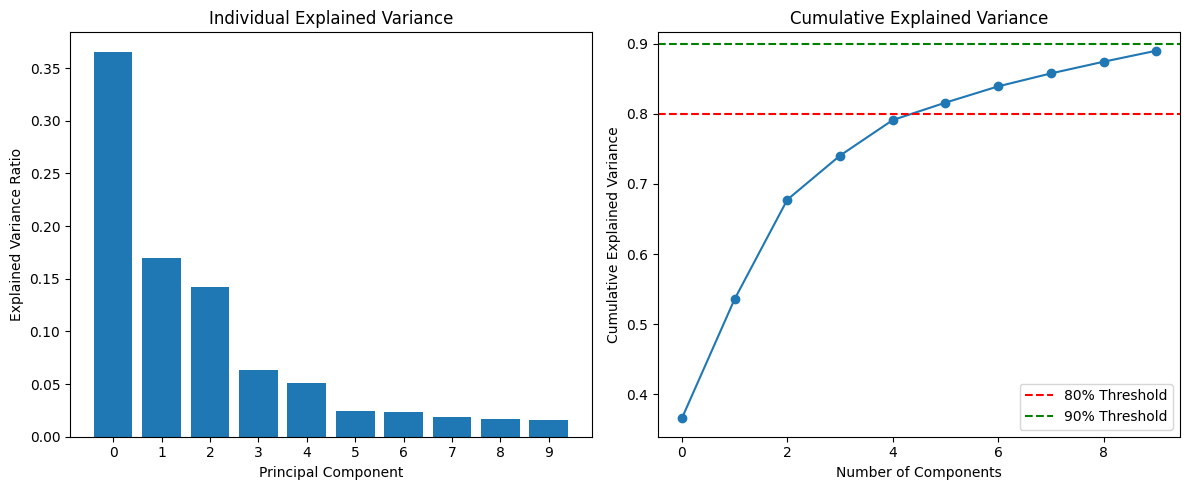

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


In [12]:
# PCA
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
pca_data: np.ndarray
pca_obj: PCA
pca_data, pca_obj = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)

In [ ]:
# save pca data
dbg_tensor(pca_data)
np.save(PATH_BASE / "pca.npy", pca_data)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[
	[col for col in DATA_SCALED.columns if col.startswith("activation.")]
]
data_meta.write_ndjson(PATH_BASE / "meta.jsonl")

[ <ipykernel>:2 ] pca_data: μ=0.00 σ=3.52 x̃=-0.07 R=[-35.88,27.20] ℙ=|   █▆  | shape=(104416,10) dtype=float64


In [33]:
dbg(len(FEATURE_COLS))
dbg_tensor(pca_obj.components_)
print()

[ <ipykernel>:1 ] len(FEATURE_COLS) = 139
[ <ipykernel>:2 ] pca_obj.components_: μ=0.01 σ=0.08 x̃=0.00 R=[-0.30,0.31] ℙ=|  ▄█▃▁ | shape=(10,139) dtype=float64


In [16]:
def pca_importance_table(
	pca_obj: PCA,
	feature_names: list[str],
) -> pl.DataFrame:
	"""Return PCA loadings plus simple importance stats.

	# Parameters:
	 - `pca_obj : PCA`
	    Fitted PCA.
	 - `feature_names : list[str]`
	    Columns used to fit the PCA.

	# Returns:
	 - `pl.DataFrame`
	    One row per feature; columns =
	    `PC0 … PCk`, `abs_sum`, `abs_mean`, `abs_max`, `abs_var`, `var_weighted`.
	"""
	# raw loadings → (n_features × n_components)
	loadings = pca_obj.components_.T
	comp_cols = [f"PC{i}" for i in range(pca_obj.n_components_)]
	df = (
		pl.DataFrame(loadings, schema=comp_cols)
		.with_columns(pl.Series("feature", feature_names))
		.select(["feature", *comp_cols])
	)

	abs_exprs = [pl.col(c).abs() for c in comp_cols]
	vw_exprs = [
		pl.col(f"PC{i}").abs() * w
		for i, w in enumerate(pca_obj.explained_variance_ratio_)
	]

	return df.with_columns(
		abs_mean=pl.sum_horizontal(abs_exprs) / len(comp_cols),
		abs_max=pl.max_horizontal(abs_exprs),
		abs_var=pl.concat_list(abs_exprs).list.var(ddof=0),  # replacement
		var_weighted=pl.sum_horizontal(vw_exprs),
	).sort("abs_mean", descending=True)


df_importance = pca_importance_table(
	pca_obj,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.beta_hist.hi…",0.132019,0.021744,0.041693,0.026644,0.050231,-0.039893,0.007525,-0.042993,0.002443,-0.043938,0.040912,0.132019,0.001157,0.064796
"""feat.log.gram.col.beta_hist.hi…",-0.131491,-0.023885,-0.029988,-0.027592,-0.058581,0.043806,-0.008661,0.040766,0.002672,0.049681,0.041712,0.131491,0.001168,0.063965
"""feat.log.gram.col.beta_hist.hi…",-0.130876,-0.018614,-0.028844,-0.032396,-0.062058,0.052676,-0.013077,0.043954,0.004689,0.046901,0.043409,0.130876,0.001146,0.063533
"""feat.log.gram.col.beta_hist.hi…",-0.130754,-0.016101,-0.057749,-0.021995,-0.035636,0.02978,0.002459,0.037141,-0.029938,0.037038,0.039859,0.130754,0.00111,0.064495
"""feat.log.gram.col.beta_hist.hi…",-0.12954,-0.02547,-0.019496,-0.0281,-0.065156,0.046702,-0.009547,0.038372,0.007077,0.054098,0.042356,0.12954,0.001163,0.062588
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.gram.row.beta_hist.hist.r…",0.002865,-0.023512,-0.053345,-0.061836,0.314323,0.03835,0.091534,0.028331,0.058157,-0.006211,0.067846,0.314323,0.007407,0.03711
"""feat.first_tok.variance""",0.002493,-0.045873,-0.002241,-0.088058,0.195627,0.085487,0.200255,-0.030599,0.248453,0.280905,0.117999,0.280905,0.009788,0.040381
"""feat.first_tok.std""",-0.001762,-0.051413,-0.011455,-0.088231,0.21202,0.067212,0.202844,-0.033565,0.248602,0.265173,0.118228,0.265173,0.009465,0.042622


In [17]:
from collections import defaultdict
from statistics import median
from typing import Literal

import polars as pl
import numpy as np


Stat = Literal["mean", "min", "max", "median"]


def aggregate_feature_stats(
	df: pl.DataFrame,
	*,
	side: int | set[int] = -1,
	abs_col: str = "abs_mean",
	feature_col: str = "feature",
) -> pl.DataFrame:
	"""Group by the first *or* last token of a dot-separated *feature* column
	and compute summary statistics for `abs_mean`.

	A minimal loop + `defaultdict` keeps things readable; only the final
	conversion to a `polars.DataFrame` uses Polars internals.

	# Parameters
	 - `df : pl.DataFrame`
	   Input data with at least `feature_col` & `abs_col`.
	 - `side : Literal["first", "last"]`
	   Which token to group on. (defaults to `"last"`)
	 - `abs_col : str`
	   Numeric column to aggregate. (defaults to `"abs_mean"`)
	 - `feature_col : str`
	   Dot-delimited feature names. (defaults to `"feature"`)

	# Returns
	 - `pl.DataFrame`
	   One row per token, with the requested statistics.

	# Usage
	```python
	out = aggregate_feature_stats(df, side="first", stats=("mean", "median"))
	```

	# Raises
	 - `ValueError` : invalid `side` or `stats` entry
	"""
	# --- simple loop, no Polars “wizardry” ---------------------------------
	groups: defaultdict[str, list[float]] = defaultdict(list)

	feat_series = df[feature_col]  # pl.Series
	val_series = df[abs_col]  # pl.Series

	for feat, val in zip(feat_series, val_series, strict=False):
		if val is None or (isinstance(val, float) and math.isnan(val)):
			continue  # skip nulls/NaNs
		token: str
		if isinstance(side, int):
			token = feat.split(".")[side]
		else:
			token = ".".join([s for i, s in enumerate(feat.split(".")) if i in side])
		groups[token].append(float(val))

	# --- compute requested statistics --------------------------------------
	rows: list[dict[str, float | str]] = []
	for token, values in groups.items():
		vals_np: np.ndarray = np.asarray(values, dtype=float)
		row: dict[str, float | str] = {"token": token}
		row["mean"] = float(vals_np.mean())
		row["min"] = float(vals_np.min())
		row["max"] = float(vals_np.max())
		row["median"] = float(median(values))  # statistics.median faster than np
		rows.append(row)

	# convert back to Polars for downstream work
	return pl.DataFrame(rows)


display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""first_tok""",0.075287,0.049504,0.118228,0.06668
"""gram""",0.06981,0.03859,0.100537,0.07101
"""log""",0.05608,0.038113,0.100355,0.055813
"""diag""",0.081186,0.066255,0.091967,0.081856
"""markov_transition""",0.047135,0.038061,0.080438,0.042245


/tmp/ipykernel_583713/3001004014.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


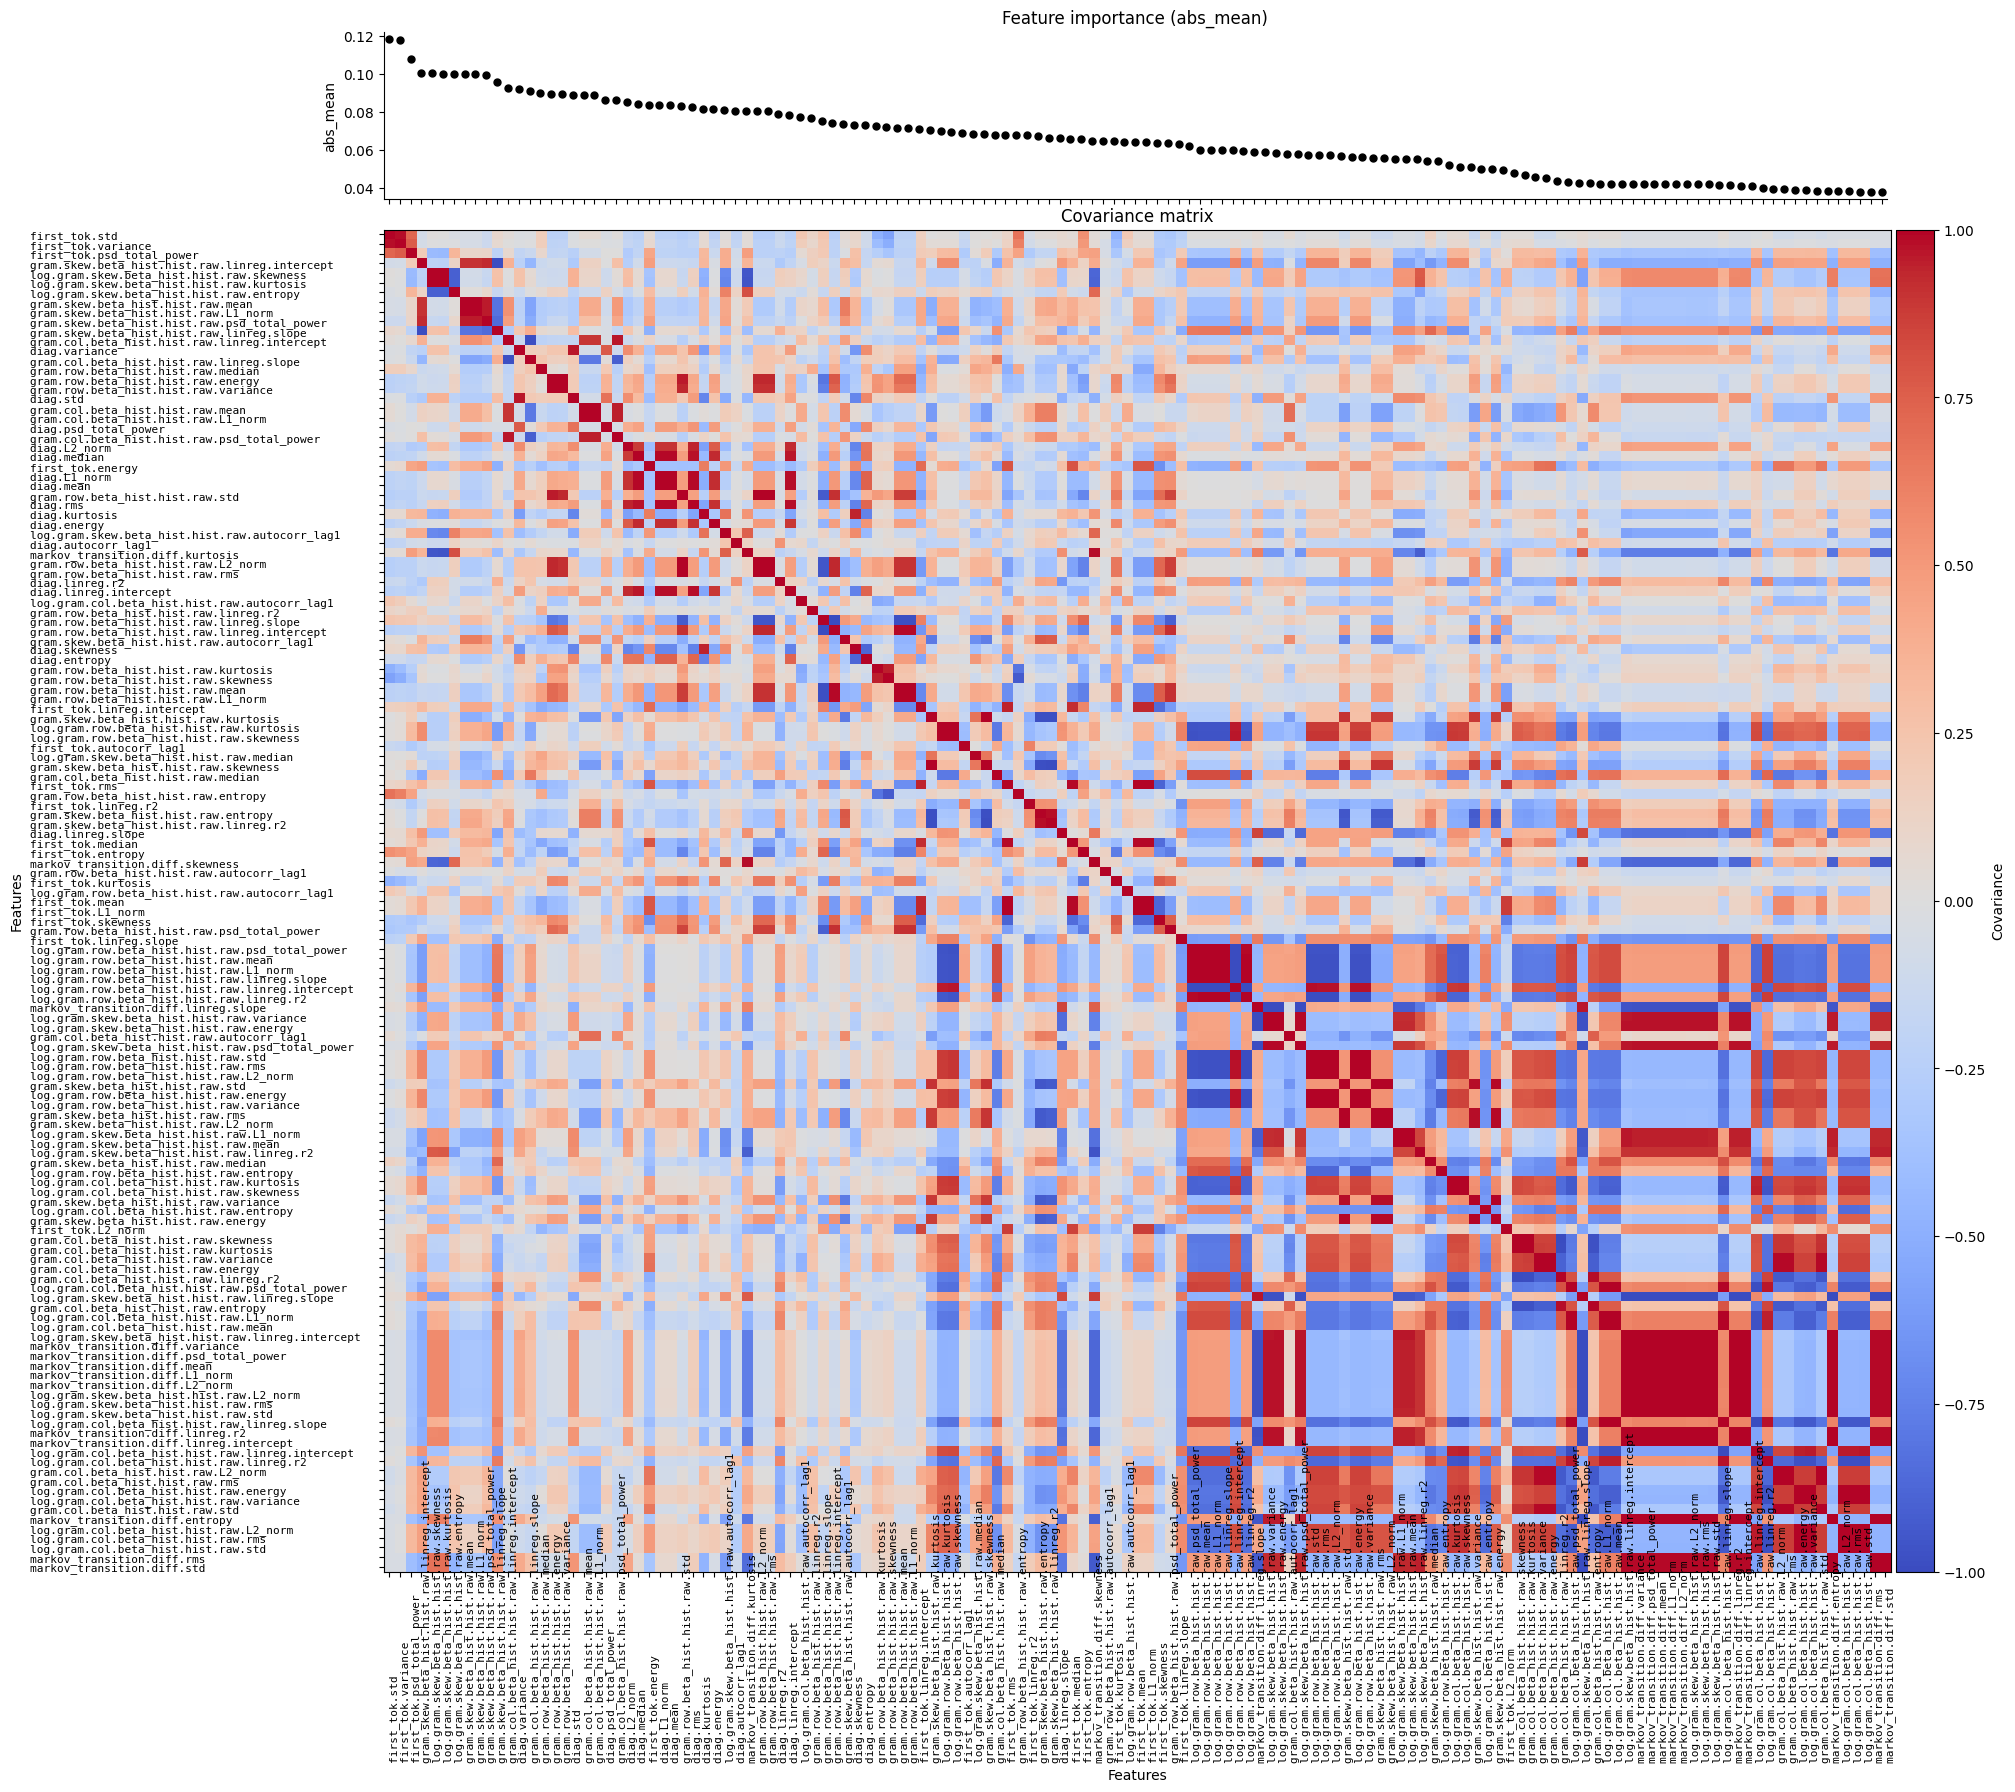

In [19]:
import numpy as np
import polars as pl
import matplotlib.gridspec as gridspec

# ------------------------------------------------------------------------
MONO_FONT = "DejaVu Sans Mono"  # any monospace installed on your system
PAD_CHARS = 2  # add this many spaces **beyond** max length
# ------------------------------------------------------------------------


def plot_importance_covariance(
	data: pl.DataFrame,
	importance_df: pl.DataFrame,
	metric: str = "abs_sum",
	descending: bool = True,
	feature_order: list[str] | None = None,  # << NEW
	bins: int | None = None,
	cmap: str = "coolwarm",
	feat_strip_prefix: str = "feat.",
	figsize: tuple[int, int] = (25, 22),
	trim_frac: float = 0.03,
	tick_pad: int = 10,  # << NEW (points; moves x-labels down)
) -> None:
	# ---------- pick feature sequence ------------------------------------
	if feature_order is not None:
		# Use the given list exactly as provided
		features = feature_order
		# Grab importance scores in that order (fill with NaNs if missing)
		scores_df = pl.DataFrame({"feature": features}).join(
			importance_df.select("feature", metric), on="feature", how="left"
		)
	else:
		# Fall back to importance-sorted order
		scores_df = importance_df.sort(metric, descending=descending).select(
			"feature", metric
		)
		features = scores_df["feature"].to_list()

	scores = scores_df[metric].to_numpy()
	labels = [f.removeprefix(feat_strip_prefix) for f in features]

	# ---------- monospace + right-padding for labels ----------------------
	max_len = max(len(lbl) for lbl in labels) + PAD_CHARS
	pad_lbls = [lbl.ljust(max_len) for lbl in labels]

	# ---------- covariance ------------------------------------------------
	cov = np.cov(data[features].to_numpy().T, bias=False)
	vmax = np.nanmax(np.abs(cov)) or 1.0

	# ---------- figure / grid --------------------------------------------
	ncols = 2 if bins else 1
	gs = gridspec.GridSpec(
		2,
		ncols,
		height_ratios=[1, 8],
		width_ratios=[20, 5] if bins else [20],
		hspace=0.04,
		wspace=0.3,
	)
	fig = plt.figure(figsize=figsize)

	# ---------- covariance heat-map --------------------------------------
	ax_cov = fig.add_subplot(gs[1, 0])
	im = ax_cov.imshow(cov, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

	ax_cov.set_xticks(range(len(features)))
	ax_cov.set_yticks(range(len(features)))
	ax_cov.set_xticklabels(
		pad_lbls,
		rotation=90,
		rotation_mode="anchor",
		fontfamily=MONO_FONT,
		fontsize=8,
	)
	ax_cov.set_yticklabels(
		pad_lbls,
		fontfamily=MONO_FONT,
		fontsize=8,
	)
	ax_cov.tick_params(axis="x", pad=tick_pad)  # << shift labels downward

	ax_cov.set_xlabel("Features")
	ax_cov.set_ylabel("Features")
	ax_cov.set_title("Covariance matrix")

	divider = make_axes_locatable(ax_cov)
	cax = divider.append_axes("right", size="2.5%", pad=0.05)
	fig.colorbar(im, cax=cax).set_label("Covariance")

	# ---------- importance dot-plot (shares x) ---------------------------
	ax_imp = fig.add_subplot(gs[0, 0], sharex=ax_cov)
	ax_imp.plot(np.arange(len(scores)), scores, "o", markersize=5, color="black")
	ax_imp.set_ylabel(metric)
	ax_imp.set_title(f"Feature importance ({metric})")
	ax_imp.tick_params(axis="x", labelbottom=False)
	for spine in ("top", "right"):
		ax_imp.spines[spine].set_visible(False)
	ax_imp.margins(x=0)

	if 0 < trim_frac < 0.5:
		pos = ax_imp.get_position()
		ax_imp.set_position([pos.x0, pos.y0, pos.width * (1 - trim_frac), pos.height])

	# ---------- optional histogram ---------------------------------------
	if bins:
		ax_hist = fig.add_subplot(gs[:, 1])
		ax_hist.hist(scores, bins=bins, orientation="horizontal", color="gray")
		ax_hist.set_xlabel("count")
		ax_hist.set_ylabel(metric)
		ax_hist.set_title("Importance distribution")
		ax_hist.invert_yaxis()

	plt.tight_layout()
	plt.show()


plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metric="abs_mean",
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
)

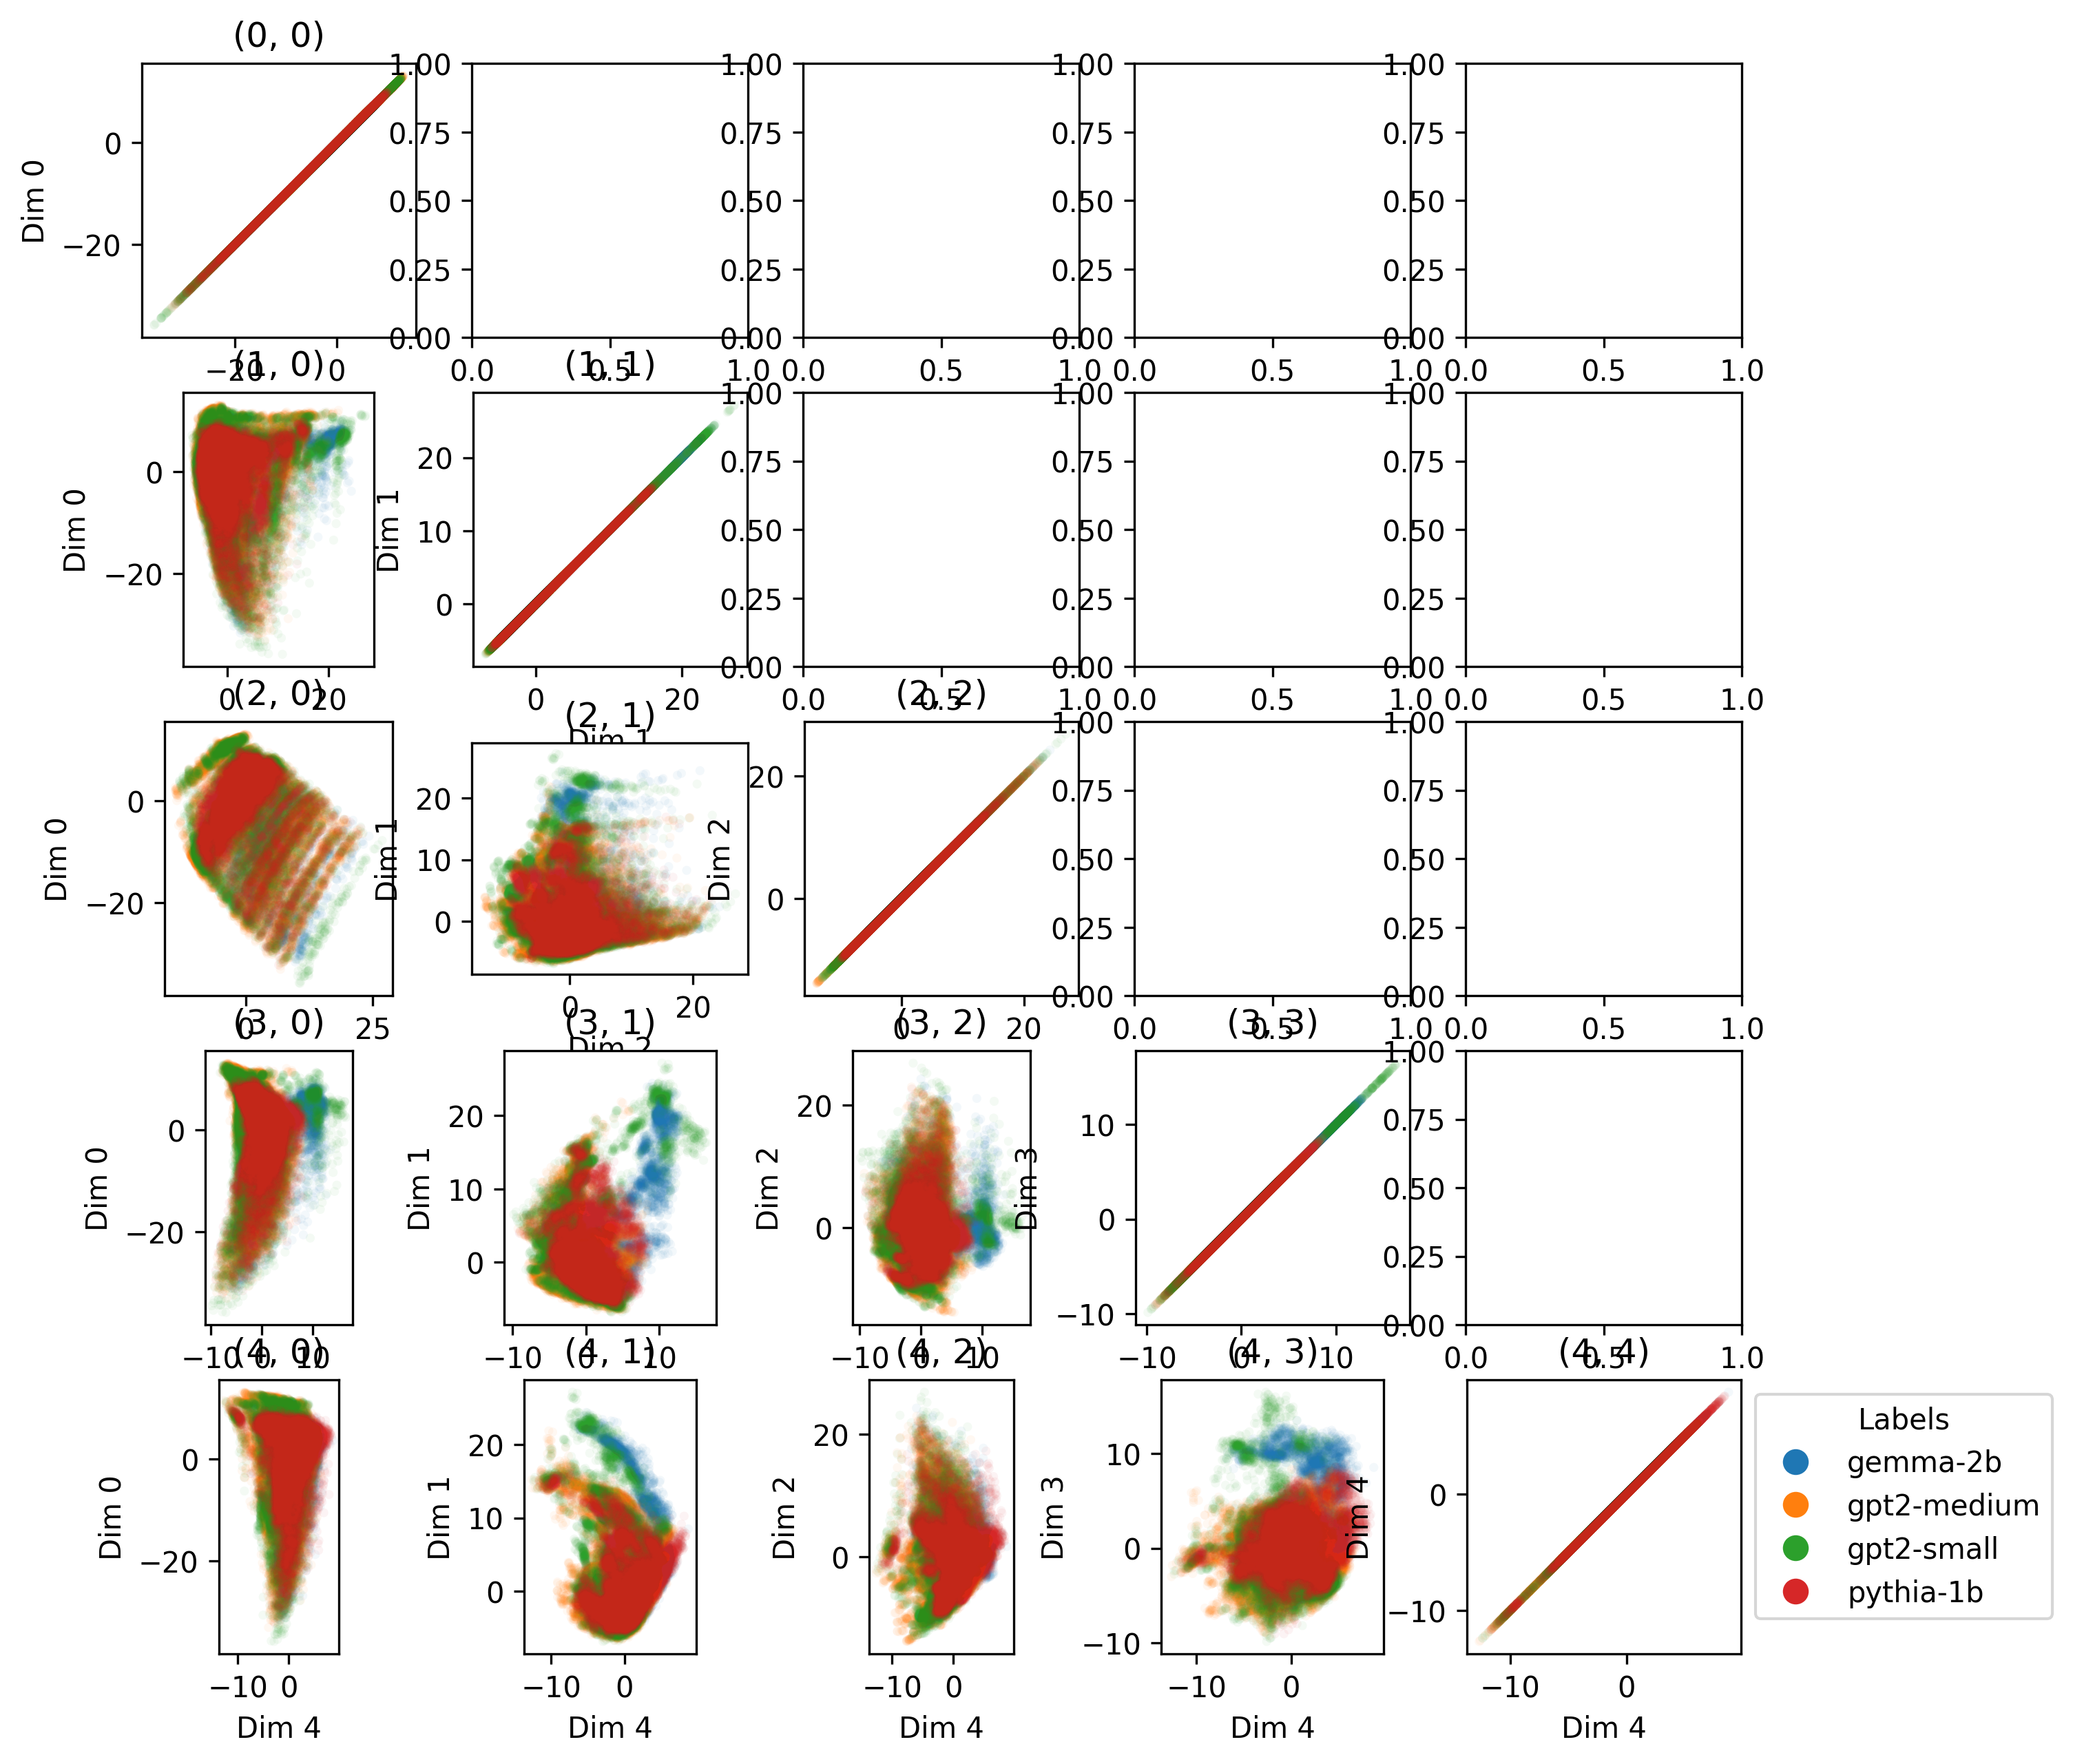

In [20]:
# DATA_REDUCED: pl.DataFrame = DATA_SCALED.select(
# 	[
# 		f for f in DATA_SCALED.columns
# 		if "markov_transition" not in f
# 	]
# )

n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims,
	n_dims,
	figsize=(10, 10),
	dpi=300,
)
for i in range(0, n_dims):
	for j in range(0, i + 1):
		plot_embedding(
			pca_data,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=10,
			title=f"({i}, {j})",
			ax=embed_ax[i, j],
		)

# distances between heads

In [21]:
DATA_SCALED

feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.skew.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.median,activation.model,feat.diag.rms,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.diff.kurtosis,feat.gram.row.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.median,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.diag.linreg.slope,feat.markov_transition.diff.variance,activation.prompt,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.diag.L1_norm,feat.first_tok.median,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.skew.beta_hist.hist.raw.entropy,feat.gram.row.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.first_tok.skewness,feat.log.gram.row.beta_hist.hist.raw.linreg.intercept,feat.diag.autocorr_lag1,feat.markov_transition.diff.rms,feat.diag.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.entropy,feat.diag.psd_total_power,feat.first_tok.energy,feat.gram.col.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.diag.mean,…,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.first_tok.rms,feat.gram.row.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.row.beta_hist.hist.raw.variance,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.psd_total_power,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.gram.col.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.rms,feat.gram.skew.beta_hist.hist.raw.skewness,feat.diag.kurtosis,feat.gram.col.beta_hist.hist.raw.skewness,feat.markov_transition.diff.skewness,feat.gram.skew.beta_hist.hist.raw.energy,activation.head,feat.diag.variance,feat.diag.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.first_tok.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.first_tok.std,activation.layer,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.log.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.first_tok.linreg.intercept
f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
-0.283626,0.796153,-0.266664,-0.494563,"""gemma-2b""",0.442892,0.473904,-1.580293,-0.057261,-0.288697,-0.552569,-0.337689,0.514015,-0.266285,"""MjWkadUxH4Z5nfLEFtUc1w""",-0.682661,0.204746,0.435085,4.061082,-0.339936,-0.32214,0.060201,-0.631021,0.724929,-0.451801,-0.21145,-0.986983,0.967734,-1.127713,0.604305,1.450932,0.075595,0.892255,-0.373188,0.493229,-0.724653,0.204746,…,-0.266664,-0.392105,0.274522,-0.238897,-0.818746,-0.008704,-0.222328,-0.159618,-0.30592,-0.340838,-0.531497,-0.252545,0.836533,-0.780488,0.878836,0.870882,1.141701,-1.266912,0.76821,0.038684,0.964072,0,1.435507,0.28935,-0.313089,-1.946191,0.839435,0.175968,0.870882,-0.663572,-0.692114,0.833364,0,-0.688287,-2.15458,-0.32214,0.155735
0.313219,0.87716,-0.268737,-1.009055,"""gemma-2b""",-0.394176,0.473904,0.443962,-0.057261,0.343294,-0.773121,-0.797421,0.417502,-0.266285,"""MjWkadUxH4Z5nfLEFtUc1w""",-0.682661,-0.382406,0.169822,-0.687573,-0.339936,0.05645,0.1780

In [ ]:
from typing import NamedTuple

import numpy as np
import polars as pl
from jaxtyping import Float


class DistanceTensorResult(NamedTuple):
    """Return object for `build_distance_tensor`."""
    cls_values: list[str]
    prompt_values: list[str]
    distances: Float[np.ndarray, 'h h p']


def build_distance_tensor(
    df: pl.DataFrame,
    *,
    cls_col: str = "activation.cls",
    prompt_col: str = "activation.prompt",
    feature_prefix: str = "feat.",
    metric: str = "l2",
) -> DistanceTensorResult:
    """
    Compute a (h, h, p) distance tensor grouped by
    (`activation.cls`, `activation.prompt`).

    Parameters
    ----------
    df
        Polars DataFrame containing feature columns and two categorical columns.
    cls_col, prompt_col
        Column names holding the categorical identifiers.
    feature_prefix
        Prefix that marks feature columns.
    metric
        ``"l2" | "euclidean"`` Euclidean distance  
        ``"l1" | "manhattan"`` Manhattan distance

    Returns
    -------
    DistanceTensorResult
        * ``cls_values``   (list[str]) - first-occurrence order of cls values  
        * ``prompt_values`` (list[str]) - first-occurrence order of prompts  
        * ``distances``     (Float[Array, 'h h p']) - distance tensor
          (`NaN` where a (cls, prompt) row is missing).
    """
    # 1. gather feature columns and unique keys (order-preserving)
    feat_cols: list[str] = [c for c in df.columns if c.startswith(feature_prefix)]

    cls_values = (
        df.select(cls_col)
        .get_column(cls_col)
        .unique(maintain_order=True)  # keep “first appearance” order
        .to_list()
    )
    prompt_values = (
        df.select(prompt_col)
        .get_column(prompt_col)
        .unique(maintain_order=True)
        .to_list()
    )

    h, p = len(cls_values), len(prompt_values)
    cls_to_i = {c: i for i, c in enumerate(cls_values)}
    prompt_to_k = {p_: k for k, p_ in enumerate(prompt_values)}

    # 2. cache vectors keyed by (cls, prompt)
    vectors: dict[tuple[str, str], np.ndarray] = {}
    for row in df.select(feat_cols + [cls_col, prompt_col]).iter_rows(named=True):
        key = (row[cls_col], row[prompt_col])
        vectors[key] = np.array([row[c] for c in feat_cols], dtype=float)

    # 3. distance selector
    metric = metric.lower()
    if metric in {"l2", "euclidean"}:
        ord_ = 2
    elif metric in {"l1", "manhattan"}:
        ord_ = 1
    else:  # defensive — fail fast
        raise ValueError(
            "metric must be 'l2'/'euclidean' or 'l1'/'manhattan', "
            f"got {metric!r}",
        )

    # 4. build tensor prompt-by-prompt
    D = np.full((h, h, p), np.nan, dtype=float)

    for prompt, k in prompt_to_k.items():
        existing_cls = [cls for cls in cls_values if (cls, prompt) in vectors]
        idxs = [cls_to_i[cls] for cls in existing_cls]
        if not idxs:  # no rows for this prompt → leave slice NaN
            continue

        X = np.vstack([vectors[(cls, prompt)] for cls in existing_cls])  # m × d
        diff = X[:, None, :] - X[None, :, :]  # m × m × d
        dist = np.linalg.norm(diff, ord=ord_, axis=-1)  # m × m

        for a, i in enumerate(idxs):
            D[i, idxs, k] = dist[a]

    return DistanceTensorResult(cls_values=cls_values, prompt_values=prompt_values, distances=D)

dist_tensor = build_distance_tensor(
    DATA_SCALED,
)


[ <ipykernel>:106 ] dist_tensor: 🚨 empty array shape=0 dtype=float64


DistanceTensorResult(cls_values=['gemma-2b:L0:H0', 'gemma-2b:L0:H1', 'gemma-2b:L0:H2', 'gemma-2b:L0:H3', 'gemma-2b:L0:H4', 'gemma-2b:L0:H5', 'gemma-2b:L0:H6', 'gemma-2b:L0:H7', 'gemma-2b:L1:H0', 'gemma-2b:L1:H1', 'gemma-2b:L1:H2', 'gemma-2b:L1:H3', 'gemma-2b:L1:H4', 'gemma-2b:L1:H5', 'gemma-2b:L1:H6', 'gemma-2b:L1:H7', 'gemma-2b:L2:H0', 'gemma-2b:L2:H1', 'gemma-2b:L2:H2', 'gemma-2b:L2:H3', 'gemma-2b:L2:H4', 'gemma-2b:L2:H5', 'gemma-2b:L2:H6', 'gemma-2b:L2:H7', 'gemma-2b:L3:H0', 'gemma-2b:L3:H1', 'gemma-2b:L3:H2', 'gemma-2b:L3:H3', 'gemma-2b:L3:H4', 'gemma-2b:L3:H5', 'gemma-2b:L3:H6', 'gemma-2b:L3:H7', 'gemma-2b:L4:H0', 'gemma-2b:L4:H1', 'gemma-2b:L4:H2', 'gemma-2b:L4:H3', 'gemma-2b:L4:H4', 'gemma-2b:L4:H5', 'gemma-2b:L4:H6', 'gemma-2b:L4:H7', 'gemma-2b:L5:H0', 'gemma-2b:L5:H1', 'gemma-2b:L5:H2', 'gemma-2b:L5:H3', 'gemma-2b:L5:H4', 'gemma-2b:L5:H5', 'gemma-2b:L5:H6', 'gemma-2b:L5:H7', 'gemma-2b:L6:H0', 'gemma-2b:L6:H1', 'gemma-2b:L6:H2', 'gemma-2b:L6:H3', 'gemma-2b:L6:H4', 'gemma-2b:L6:

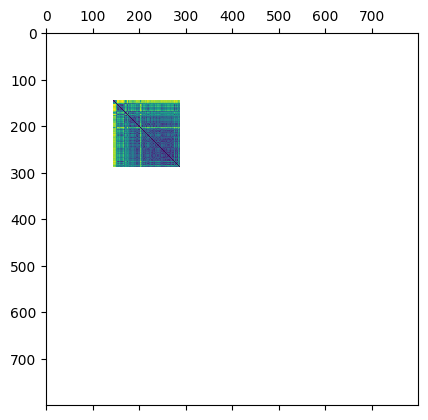

In [26]:
plt.matshow(
	dist_tensor.distances.mean(axis=-1),
)